In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from initiator import Underlying, Option
from scipy.stats import norm

In [2]:
node_labels = {}
G= nx.DiGraph()
G.add_node((1,1))
node_labels[(1,1)] = 100
G.add_node((2,1))
node_labels[(2,1)] = 80
G.add_node((2,2))
node_labels[(2,2)] = 120
G.add_node((3,1))
node_labels[(3,1)] = 64
G.add_node((3,2))
node_labels[(3,2)] = 96
G.add_node((3,3))
node_labels[(3,3)] = 144
G.add_edge((1,1), (2,1))
G.add_edge((1,1), (2,2))
G.add_edge((2,2), (3,3))
G.add_edge((2,2), (3,2))
G.add_edge((2,1), (3,1))
G.add_edge((2,1), (3,2))

In [3]:
G.nodes()

NodeView(((1, 1), (2, 1), (2, 2), (3, 1), (3, 2), (3, 3)))

In [86]:
def build_tree(S, u, d, steps=3):
    G = nx.DiGraph()
    node_labels = {}
    for i in range(steps):
        for j in range(i+1):
            # print('i, j: ', i, j)
            G.add_node((i+1, j+1))
            node_labels[(i+1, j+1)] = round(S * (u**j) * (d**(i-j)), 2)

            if i>0 and (i, j+1) in node_labels:
                G.add_edge((i,j+1), (i+1, j+1))
            if i>0 and (i, j) in node_labels:
                G.add_edge((i, j), (i+1, j+1))
    pos = {node: (node[0], node[1] - node[0] / 2) for node in G.nodes()}
    return G, pos, node_labels

def build_tree_small_time(S, u, d, t=1, steps=3):
    G = nx.DiGraph()
    delta_t = t/(steps-1)
    node_labels = {}

    # u_new = 1 + ((u-1) * delta_t)
    # print((u-1) * delta_t)
    # d_new = 1 - ((1-d) * delta_t)


    
    sigma = np.log(u/d) / (2 * np.sqrt(t))
    u_new = np.exp(sigma * np.sqrt(delta_t))
    d_new = 1/u_new


    
    print('u_new : ', u_new)
    print('d_new : ', d_new)
    for i in range(steps):
        for j in range(i+1):
            # print('i, j: ', i, j)
            G.add_node((i+1, j+1))
            node_labels[(i+1, j+1)] = round(S * np.exp(j * np.log(u_new) + (i - j) * np.log(d_new)), 2)

            if i>0 and (i, j+1) in node_labels:
                G.add_edge((i,j+1), (i+1, j+1))
            if i>0 and (i, j) in node_labels:
                G.add_edge((i, j), (i+1, j+1))
    pos = {node: (node[0], node[1] - node[0] / 2) for node in G.nodes()}
    return G, pos, node_labels

def calculate_price(G, node_labels, p_u, r, option, steps):
    p_d = 1 - p_u
    op_price_node = {}
    for k, v in dict(sorted(node_labels.items(), key=lambda item: item[0][0], reverse=True)).items():
        # print(k)
        if k[0] == steps:
            op_price_node[k] = round((max(0, v - option.strike_price) if option.call_or_put == 'call' else max(0, option.strike_price - v)), 2)
        else:
            count_step = k[0] + 1
            up = k[1] + 1
            down = k[1]
            up_node = (count_step, up)
            down_node = (count_step, down)
            op_price_node[k] = round(max(0, (p_u * op_price_node[up_node] + p_d * op_price_node[down_node])/(1+r)), 2)
    return op_price_node

def calculate_price_small_time(G, node_labels, p_u, r, option, t, steps):
    op_price_node = {}
    delta_t = t/(steps-1)

    S0 = node_labels[(1, 1)]
    u_new = node_labels[(2, 2)] / S0
    d_new = node_labels[(2, 1)] / S0

    disc = np.exp(-r * delta_t)

    if p_u is None:
        p_u = (np.exp(r*delta_t) - d_new) / (u_new - d_new)

    p_d = 1 - p_u
    
    for k, v in dict(sorted(node_labels.items(), key=lambda item: item[0][0], reverse=True)).items():
        # print(k)
        if k[0] == steps:
            op_price_node[k] = round((max(0, v - option.strike_price) if option.call_or_put == 'call' else max(0, option.strike_price - v)), 2)
        else:
            count_step = k[0] + 1
            up = k[1] + 1
            down = k[1]
            up_node = (count_step, up)
            down_node = (count_step, down)
            # op_price_node[k] = round(max(0, (p_u * op_price_node[up_node] + p_d * op_price_node[down_node])/((1+r_new))), 2)
            
            op_price_node[k] = round(disc * (p_u * op_price_node[up_node] + p_d * op_price_node[down_node]), 2)
    return op_price_node
    



underlying = Underlying(current_price=100, predicted_price=100, position='long')
option = Option('call', 'long', 100, 2.7, 'Mar 26', 1, underlying, quantity=1)


start_node = (1,1)
steps_ = 25
G_b, pos_b, node_labels_b = build_tree_small_time(100, 1.25, 0.8, t=1, steps=steps_)
op_price_node = calculate_price_small_time(G_b, node_labels_b, None, 0.025, option, 1, steps_)

op_price = op_price_node[start_node]

u_new :  1.046602272924683
d_new :  0.9554727959892012


In [87]:
1/3

0.3333333333333333

In [88]:
op_price_node

{(25, 1): 0,
 (25, 2): 0,
 (25, 3): 0,
 (25, 4): 0,
 (25, 5): 0,
 (25, 6): 0,
 (25, 7): 0,
 (25, 8): 0,
 (25, 9): 0,
 (25, 10): 0,
 (25, 11): 0,
 (25, 12): 0,
 (25, 13): 0,
 (25, 14): np.float64(9.54),
 (25, 15): np.float64(19.98),
 (25, 16): np.float64(31.43),
 (25, 17): np.float64(43.96),
 (25, 18): np.float64(57.69),
 (25, 19): np.float64(72.73),
 (25, 20): np.float64(89.21),
 (25, 21): np.float64(107.26),
 (25, 22): np.float64(127.02),
 (25, 23): np.float64(148.68),
 (25, 24): np.float64(172.39),
 (25, 25): np.float64(198.37),
 (24, 1): np.float64(0.0),
 (24, 2): np.float64(0.0),
 (24, 3): np.float64(0.0),
 (24, 4): np.float64(0.0),
 (24, 5): np.float64(0.0),
 (24, 6): np.float64(0.0),
 (24, 7): np.float64(0.0),
 (24, 8): np.float64(0.0),
 (24, 9): np.float64(0.0),
 (24, 10): np.float64(0.0),
 (24, 11): np.float64(0.0),
 (24, 12): np.float64(0.0),
 (24, 13): np.float64(4.76),
 (24, 14): np.float64(14.74),
 (24, 15): np.float64(25.68),
 (24, 16): np.float64(37.65),
 (24, 17): np.flo

In [89]:
for k in op_price_node:
    print(k, node_labels_b[k], ' : ', op_price_node[k])

(25, 1) 33.52  :  0
(25, 2) 36.71  :  0
(25, 3) 40.21  :  0
(25, 4) 44.05  :  0
(25, 5) 48.25  :  0
(25, 6) 52.85  :  0
(25, 7) 57.89  :  0
(25, 8) 63.41  :  0
(25, 9) 69.46  :  0
(25, 10) 76.09  :  0
(25, 11) 83.34  :  0
(25, 12) 91.29  :  0
(25, 13) 100.0  :  0
(25, 14) 109.54  :  9.54
(25, 15) 119.98  :  19.98
(25, 16) 131.43  :  31.43
(25, 17) 143.96  :  43.96
(25, 18) 157.69  :  57.69
(25, 19) 172.73  :  72.73
(25, 20) 189.21  :  89.21
(25, 21) 207.26  :  107.26
(25, 22) 227.02  :  127.02
(25, 23) 248.68  :  148.68
(25, 24) 272.39  :  172.39
(25, 25) 298.37  :  198.37
(24, 1) 35.08  :  0.0
(24, 2) 38.42  :  0.0
(24, 3) 42.09  :  0.0
(24, 4) 46.1  :  0.0
(24, 5) 50.5  :  0.0
(24, 6) 55.31  :  0.0
(24, 7) 60.59  :  0.0
(24, 8) 66.37  :  0.0
(24, 9) 72.7  :  0.0
(24, 10) 79.63  :  0.0
(24, 11) 87.23  :  0.0
(24, 12) 95.55  :  0.0
(24, 13) 104.66  :  4.76
(24, 14) 114.64  :  14.74
(24, 15) 125.58  :  25.68
(24, 16) 137.55  :  37.65
(24, 17) 150.67  :  50.77
(24, 18) 165.04  :  65.14
(

In [90]:
op_price

np.float64(9.94)

In [91]:
def calculate_black_scholes_crr(underlying, option, u, r, steps):
    
    S = underlying.current_price
    print('S : ', S)
    K = option.strike_price
    print('K : ', K)
    T = 1
    print('T : ', T)
    r = r
    print('r : ', r)
    sigma = np.log(u)/np.sqrt(T)
    print('sigma : ', sigma)

    d1 = np.log(S / K) + (r + 0.5 * sigma**2 * T)/(sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    if option.call_or_put == 'call':
        price = S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    elif option.call_or_put == 'put':
        price = K * np.exp(-r * T) * norm.cdf(d2) - S * norm.cdf(d1)

    return price
    

In [92]:
black_scholes_crr_price = calculate_black_scholes_crr(underlying, option, 1.25, 0.025, steps_)

print(black_scholes_crr_price)

S :  100
K :  100
T :  1
r :  0.025
sigma :  0.22314355131420976
10.063316146408809


{(1, 1): Text(1, 0.5, '100.0'),
 (2, 1): Text(2, 0.0, '95.55'),
 (2, 2): Text(2, 1.0, '104.66'),
 (3, 1): Text(3, -0.5, '91.29'),
 (3, 2): Text(3, 0.5, '100.0'),
 (3, 3): Text(3, 1.5, '109.54'),
 (4, 1): Text(4, -1.0, '87.23'),
 (4, 2): Text(4, 0.0, '95.55'),
 (4, 3): Text(4, 1.0, '104.66'),
 (4, 4): Text(4, 2.0, '114.64'),
 (5, 1): Text(5, -1.5, '83.34'),
 (5, 2): Text(5, -0.5, '91.29'),
 (5, 3): Text(5, 0.5, '100.0'),
 (5, 4): Text(5, 1.5, '109.54'),
 (5, 5): Text(5, 2.5, '119.98'),
 (6, 1): Text(6, -2.0, '79.63'),
 (6, 2): Text(6, -1.0, '87.23'),
 (6, 3): Text(6, 0.0, '95.55'),
 (6, 4): Text(6, 1.0, '104.66'),
 (6, 5): Text(6, 2.0, '114.64'),
 (6, 6): Text(6, 3.0, '125.58'),
 (7, 1): Text(7, -2.5, '76.09'),
 (7, 2): Text(7, -1.5, '83.34'),
 (7, 3): Text(7, -0.5, '91.29'),
 (7, 4): Text(7, 0.5, '100.0'),
 (7, 5): Text(7, 1.5, '109.54'),
 (7, 6): Text(7, 2.5, '119.98'),
 (7, 7): Text(7, 3.5, '131.43'),
 (8, 1): Text(8, -3.0, '72.7'),
 (8, 2): Text(8, -2.0, '79.63'),
 (8, 3): Text(8, -

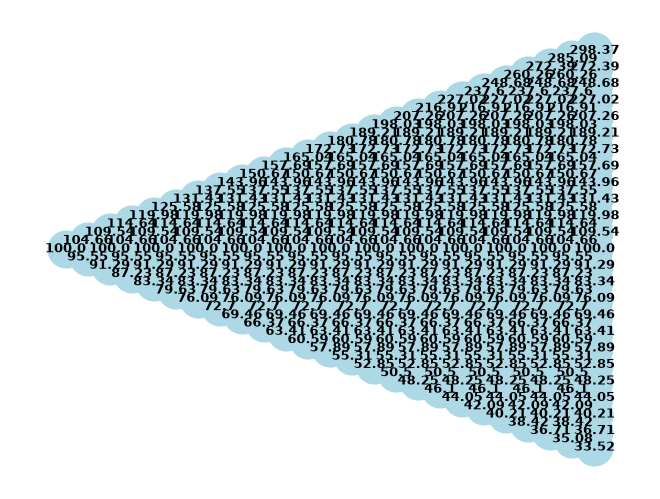

In [93]:
nx.draw(
    G_b,
    pos_b,
    with_labels=False,
    node_color="lightblue",
    node_size=700,
    arrows=True
)

nx.draw_networkx_labels(G_b, pos_b, labels=node_labels_b, font_size=9, font_weight='bold')

{(25, 1): Text(25, -11.5, '0'),
 (25, 2): Text(25, -10.5, '0'),
 (25, 3): Text(25, -9.5, '0'),
 (25, 4): Text(25, -8.5, '0'),
 (25, 5): Text(25, -7.5, '0'),
 (25, 6): Text(25, -6.5, '0'),
 (25, 7): Text(25, -5.5, '0'),
 (25, 8): Text(25, -4.5, '0'),
 (25, 9): Text(25, -3.5, '0'),
 (25, 10): Text(25, -2.5, '0'),
 (25, 11): Text(25, -1.5, '0'),
 (25, 12): Text(25, -0.5, '0'),
 (25, 13): Text(25, 0.5, '0'),
 (25, 14): Text(25, 1.5, '9.54'),
 (25, 15): Text(25, 2.5, '19.98'),
 (25, 16): Text(25, 3.5, '31.43'),
 (25, 17): Text(25, 4.5, '43.96'),
 (25, 18): Text(25, 5.5, '57.69'),
 (25, 19): Text(25, 6.5, '72.73'),
 (25, 20): Text(25, 7.5, '89.21'),
 (25, 21): Text(25, 8.5, '107.26'),
 (25, 22): Text(25, 9.5, '127.02'),
 (25, 23): Text(25, 10.5, '148.68'),
 (25, 24): Text(25, 11.5, '172.39'),
 (25, 25): Text(25, 12.5, '198.37'),
 (24, 1): Text(24, -11.0, '0.0'),
 (24, 2): Text(24, -10.0, '0.0'),
 (24, 3): Text(24, -9.0, '0.0'),
 (24, 4): Text(24, -8.0, '0.0'),
 (24, 5): Text(24, -7.0, '0.0')

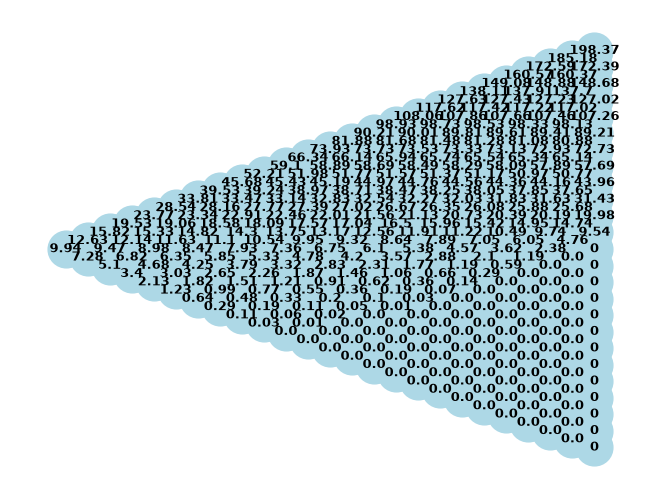

In [94]:
nx.draw(
    G_b,
    pos_b,
    with_labels=False,
    node_color="lightblue",
    node_size=700,
    arrows=True
)

nx.draw_networkx_labels(G_b, pos_b, labels=op_price_node, font_size=9, font_weight='bold')

In [95]:
(125+80)/2 / 100

1.025

In [67]:
(1/4*156.25 + 1/2*100 + 1/4*64) / (1.025)**2

100.00000000000001